In [15]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

# load the Train, Test and Validate Dataset

In [16]:
train_df = pd.read_csv("../Dataset/train_metadata.csv")
valid_df = pd.read_csv("../Dataset/valid_metadata.csv")
test_df = pd.read_csv("../Dataset/test_metadata.csv")

In [17]:
train_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0033319...,450,600
1,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,../Dataset/HAM10000_images_part_2\ISIC_0030823...,450,600
2,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0028730...,450,600
3,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0027299...,450,600
4,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,../Dataset/HAM10000_images_part_2\ISIC_0032444...,450,600
...,...,...,...,...,...,...,...,...,...,...
8007,HAM_0000940,ISIC_0032692,vasc,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0032692...,450,600
8008,HAM_0005629,ISIC_0029317,nv,follow_up,45.0,female,upper extremity,../Dataset/HAM10000_images_part_2\ISIC_0029317...,450,600
8009,HAM_0004025,ISIC_0025983,nv,histo,20.0,female,abdomen,../Dataset/HAM10000_images_part_1\ISIC_0025983...,450,600
8010,HAM_0004542,ISIC_0027256,vasc,consensus,0.0,female,back,../Dataset/HAM10000_images_part_1\ISIC_0027256...,450,600


In [18]:
valid_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0005031,ISIC_0025109,nv,follow_up,65.0,male,abdomen,../Dataset/HAM10000_images_part_1\ISIC_0025109...,450,600
1,HAM_0006188,ISIC_0024330,df,consensus,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0024330...,450,600
2,HAM_0007094,ISIC_0026785,nv,follow_up,30.0,female,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0026785...,450,600
3,HAM_0006129,ISIC_0029560,nv,histo,45.0,male,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0029560...,450,600
4,HAM_0005351,ISIC_0032590,nv,histo,20.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0032590...,450,600
...,...,...,...,...,...,...,...,...,...,...
996,HAM_0001187,ISIC_0027914,nv,follow_up,45.0,male,trunk,../Dataset/HAM10000_images_part_1\ISIC_0027914...,450,600
997,HAM_0006973,ISIC_0029377,nv,follow_up,60.0,male,trunk,../Dataset/HAM10000_images_part_2\ISIC_0029377...,450,600
998,HAM_0006723,ISIC_0026365,bkl,histo,45.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0026365...,450,600
999,HAM_0000434,ISIC_0031635,nv,follow_up,45.0,female,trunk,../Dataset/HAM10000_images_part_2\ISIC_0031635...,450,600


In [19]:
test_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0006303,ISIC_0026911,nv,histo,55.0,male,abdomen,../Dataset/HAM10000_images_part_1\ISIC_0026911...,450,600
1,HAM_0002614,ISIC_0027637,nv,follow_up,75.0,male,trunk,../Dataset/HAM10000_images_part_1\ISIC_0027637...,450,600
2,HAM_0004362,ISIC_0031873,nv,follow_up,45.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0031873...,450,600
3,HAM_0006207,ISIC_0030034,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2\ISIC_0030034...,450,600
4,HAM_0000801,ISIC_0025619,nv,histo,20.0,female,back,../Dataset/HAM10000_images_part_1\ISIC_0025619...,450,600
...,...,...,...,...,...,...,...,...,...,...
997,HAM_0006197,ISIC_0028332,nv,histo,40.0,male,back,../Dataset/HAM10000_images_part_1\ISIC_0028332...,450,600
998,HAM_0006935,ISIC_0026628,nv,follow_up,50.0,male,back,../Dataset/HAM10000_images_part_1\ISIC_0026628...,450,600
999,HAM_0004607,ISIC_0031642,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2\ISIC_0031642...,450,600
1000,HAM_0004399,ISIC_0028905,nv,histo,20.0,female,face,../Dataset/HAM10000_images_part_1\ISIC_0028905...,450,600


# Resize images

In [20]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Load and Resize Images

In [21]:
def load_images(dataframe):

    images = []
    labels = []

    for index, row in dataframe.iterrows():

        image = cv2.imread(row["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

        images.append(image)
        labels.append(row["dx"])

    return np.array(images), np.array(labels)

In [ ]:
X_train, y_train = load_images(train_df)
X_valid, y_valid = load_images(valid_df)
X_test, y_test = load_images(test_df)

In [ ]:
X_train

array([[[[129,  85,  79],
         [129,  82,  77],
         [135,  86,  80],
         ...,
         [154, 112, 113],
         [152, 108, 112],
         [147, 105, 107]],

        [[132,  86,  78],
         [133,  85,  76],
         [140,  91,  83],
         ...,
         [154, 112, 113],
         [151, 109, 111],
         [150, 108, 110]],

        [[133,  85,  75],
         [138,  89,  82],
         [139,  91,  81],
         ...,
         [160, 117, 119],
         [157, 113, 116],
         [153, 111, 112]],

        ...,

        [[158, 116, 118],
         [162, 120, 122],
         [160, 120, 121],
         ...,
         [181, 139, 143],
         [177, 133, 137],
         [177, 135, 139]],

        [[158, 118, 119],
         [161, 120, 123],
         [158, 116, 117],
         ...,
         [186, 144, 153],
         [180, 137, 142],
         [176, 134, 138]],

        [[158, 118, 119],
         [159, 118, 120],
         [160, 119, 120],
         ...,
         [187, 146, 158],
        

In [ ]:
y_train

array(['nv', 'nv', 'akiec', ..., 'nv', 'vasc', 'nv'],
      shape=(8012,), dtype='<U5')

In [ ]:
X_valid

array([[[[222, 144, 163],
         [218, 140, 159],
         [223, 139, 159],
         ...,
         [133,  64,  73],
         [161,  76,  87],
         [214, 135, 149]],

        [[219, 143, 159],
         [217, 139, 154],
         [221, 134, 157],
         ...,
         [171, 108, 115],
         [141,  63,  70],
         [190, 100, 116]],

        [[220, 141, 157],
         [218, 140, 155],
         [221, 137, 157],
         ...,
         [206, 139, 144],
         [138,  73,  78],
         [145,  57,  70]],

        ...,

        [[158,  86,  85],
         [129,  72,  74],
         [186, 133, 133],
         ...,
         [204, 141, 149],
         [200, 141, 146],
         [200, 141, 144]],

        [[130,  59,  62],
         [163, 106, 109],
         [188, 134, 131],
         ...,
         [207, 143, 152],
         [202, 138, 145],
         [202, 139, 147]],

        [[106,  35,  38],
         [183, 127, 132],
         [192, 132, 133],
         ...,
         [207, 140, 150],
        

In [ ]:
y_valid

array(['nv', 'df', 'nv', ..., 'bkl', 'nv', 'mel'],
      shape=(1001,), dtype='<U5')

In [ ]:
X_test

array([[[[150, 123, 140],
         [151, 124, 141],
         [149, 124, 143],
         ...,
         [133, 111, 120],
         [134, 108, 117],
         [134, 108, 117]],

        [[149, 122, 139],
         [150, 123, 140],
         [149, 124, 143],
         ...,
         [136, 112, 122],
         [135, 109, 118],
         [134, 108, 117]],

        [[147, 120, 137],
         [149, 122, 139],
         [148, 123, 142],
         ...,
         [136, 113, 123],
         [137, 111, 120],
         [136, 110, 119]],

        ...,

        [[129, 101, 116],
         [132, 105, 120],
         [134, 107, 122],
         ...,
         [126,  98, 102],
         [124,  95,  99],
         [122,  93,  97]],

        [[123, 101, 114],
         [127, 105, 118],
         [132, 105, 120],
         ...,
         [123,  97, 100],
         [123,  94,  98],
         [120,  91,  95]],

        [[121, 101, 113],
         [125, 105, 118],
         [131, 103, 119],
         ...,
         [121,  95,  98],
        

In [ ]:
y_test

array(['nv', 'nv', 'nv', ..., 'mel', 'nv', 'nv'],
      shape=(1002,), dtype='<U5')

In [ ]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(8012, 224, 224, 3)
(1001, 224, 224, 3)
(1002, 224, 224, 3)


# Normalize the Images

In [ ]:
import numpy as np

X_train = X_train.astype("float32", copy=False)
X_train /= 255.0

X_valid = X_valid.astype("float32", copy=False)
X_valid /= 255.0

X_test = X_test.astype("float32", copy=False)
X_test /= 255.0

MemoryError: Unable to allocate 4.49 GiB for an array with shape (8012, 224, 224, 3) and data type float32

In [ ]:
image = tf.io.read_file("../Dataset/HAM10000_images_part_1/ISIC_002406.jpg")
image

NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} NewRandomAccessFile failed to Create/Open: ../Dataset/HAM10000_images_part_1/ISIC_002406.jpg : The system cannot find the file specified.
; No such file or directory [Op:ReadFile]

In [ ]:
import tensorflow as tf

IMG_SIZE = (224,224)

def process_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    return image, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["path"], train_df["dx"])
)

train_ds = train_ds.map(process_image)
train_ds = train_ds.batch(32)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None))>

# Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["dx"])
valid_df["label"] = label_encoder.transform(valid_df["dx"])
test_df["label"] = label_encoder.transform(test_df["dx"])

print(label_encoder.classes_)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


# Compute Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


# Create Image Loading Function

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)

def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create Augmentation Pipeline

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# Create TensorFlow Dataset

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["path"], train_df["label"])
)

train_dataset = train_dataset.map(process_image)

# Apply Augmentation

In [ ]:
# Training Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["path"].values, train_df["label"].values)
)

train_dataset = train_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Validation Dataset
valid_dataset = tf.data.Dataset.from_tensor_slices(
    (valid_df["path"].values, valid_df["label"].values)
)

valid_dataset = valid_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Test Dataset
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df["path"].values, test_df["label"].values)
)

test_dataset = test_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch the Dataset

In [ ]:
BATCH_SIZE = 32

train_dataset = train_dataset.batch(BATCH_SIZE)
valid_dataset = valid_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

# Cache and Prefetch

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
valid_dataset = valid_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

# Verify the Pipeline

In [ ]:
for images, labels in train_dataset.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [ ]:
for images, labels in train_dataset.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)
    print("Image Data Type :", images.dtype)
    print("Label Data Type :", labels.dtype)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)
Image Data Type : <dtype: 'float32'>
Label Data Type : <dtype: 'int64'>


# Visualize an Augmented Batch

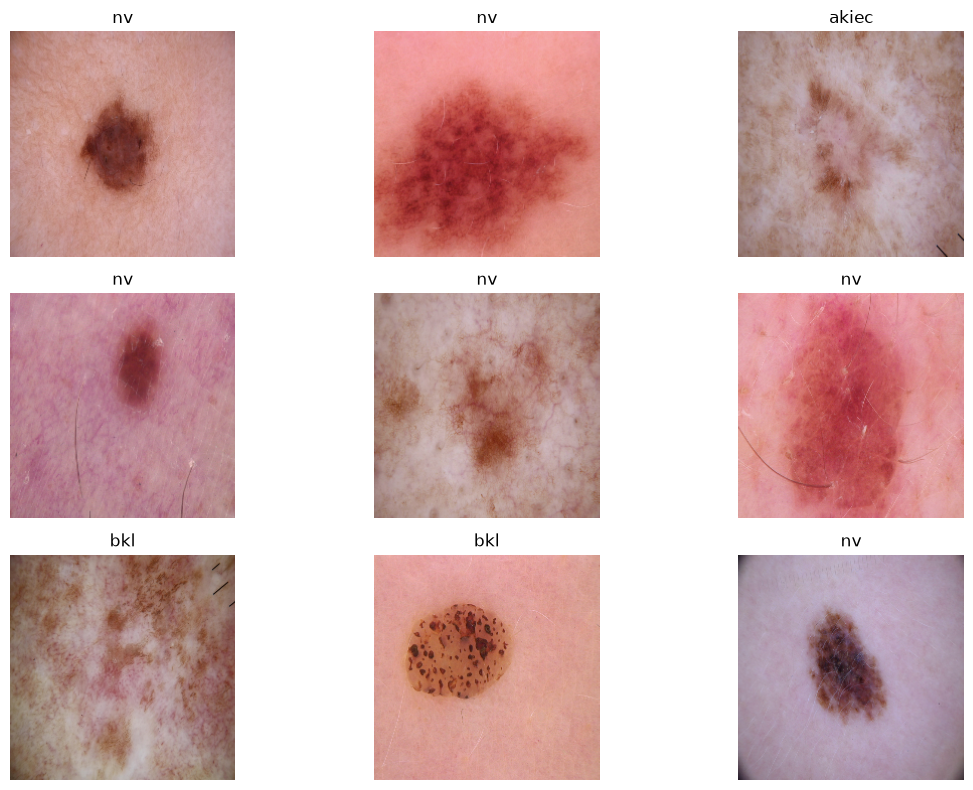

In [ ]:
import matplotlib.pyplot as plt

class_names = label_encoder.classes_

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 8))

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        plt.title(class_names[labels[i]])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Save the Label Mapping

In [ ]:
import json

label_mapping = {
    int(v): k
    for v, k in enumerate(label_encoder.classes_)
}

with open("label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

print(label_mapping)

{0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
